Implementation of MCP neuron

AND

In [1]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operations with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [2]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print(result)

[0, 0, 0, 1]


OR

In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [4]:
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(result_or)

[0, 1, 1, 1]


Question 1: Limitations of MCP neurons



The MCP neuron has several limitations. It is a highly simplified model of a biological neuron and does not accurately represent the complex behavior of real neurons. It only works with binary inputs and binary outputs, which makes it too limited for many real-world problems. The threshold value must usually be chosen manually, so the neuron does not learn automatically from data. Another major limitation is that a single MCP neuron can only solve linearly separable problems, such as AND and OR, but it cannot solve non-linearly separable problems like XOR. It also does not use trainable weights in its simplest form, making it less flexible than later models such as the perceptron. Because of these limitations, MCP neurons are mainly important as a historical foundation for the development of artificial neural networks rather than as practical modern learning models.

Question 2: Can MCP neuron solve XOR?

A single MCP neuron cannot solve the XOR function because XOR is not linearly separable. The MCP neuron works by summing the inputs and comparing the result with a single threshold value. For XOR, the output should be 1 when the input sum is 1, but 0 when the input sum is 0 or 2. No single threshold can satisfy these conditions at the same time. Therefore, XOR cannot be implemented using one basic MCP neuron with a simple if-else threshold rule. It would require multiple neurons arranged in layers.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Implementation for 0 Vs. 1 Classification.


## Step 1: Load the Dataset


### Viewing the Dataset.


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_0_1 = pd.read_csv("/content/drive/MyDrive/Datasets/mnist_0_and_1 (1).csv")

# X contains the pixel values (784 features)
X = df_0_1.drop(columns=["label"]).values

# y contains the class labels (0 or 1)
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


 Step 2: Visualize first 5 images of 0 and 1

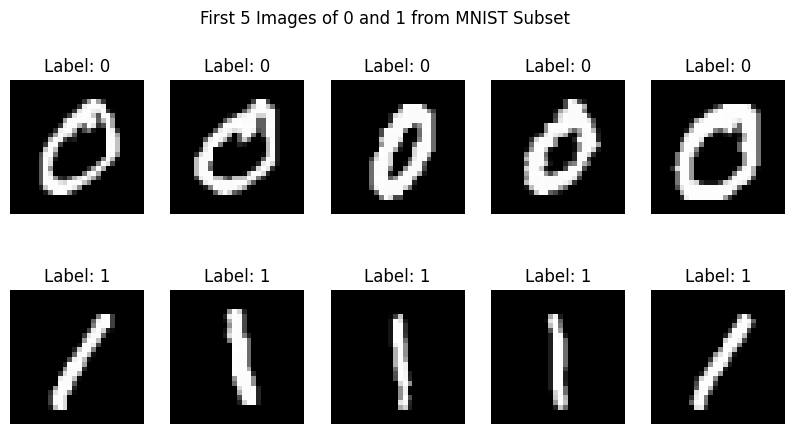

In [44]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images to display.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

Step 3: Initialize weights and bias

In [45]:
weights = np.zeros(X.shape[1])   # one weight for each of the 784 pixels
bias = 0
learning_rate = 0.1
epochs = 100



Feature matrix shape: (2741, 784)
Label vector shape: (2741,)
Binary labels after conversion: [0 1]


Step 4: Decision function

In [46]:
def decision_function(X, weights, bias):
    """
    Compute predicted labels using the perceptron step function.
    """
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

Step 5: Train perceptron

In [47]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron model using the perceptron learning rule.
    """
    for epoch in range(epochs):
        errors = 0

        for i in range(len(X)):
            # Net input for one sample
            output = np.dot(X[i], weights) + bias

            # Step activation
            y_pred = 1 if output >= 0 else 0

            # Update if wrong
            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)
                errors += 1

        # Stop if no errors in this epoch
        if errors == 0:
            break

    # Compute final predictions and accuracy
    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.mean(y_pred_all == y)

    return weights, bias, accuracy


Step 6: Train and evaluate

In [48]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)

print("Final Accuracy:", accuracy)

Final Accuracy: 1.0


Step 7: Visualize misclassified images

In [49]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Task 3: Perceptron for 3 vs 5

In [50]:
df_3_5 = pd.read_csv("/content/drive/MyDrive/Datasets/mnist_3_and_5 (1).csv")

# Extract features and labels
X = df_3_5.drop(columns=["label"]).values   # 784 pixel values
y = df_3_5["label"].values                  # labels are 3 and 5

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

# Convert labels to binary for perceptron
# 3 -> 0, 5 -> 1
y = np.where(y == 5, 1, 0)

print("Binary labels after conversion:", np.unique(y))

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)
Binary labels after conversion: [0 1]


Step 2: Visualize sample images

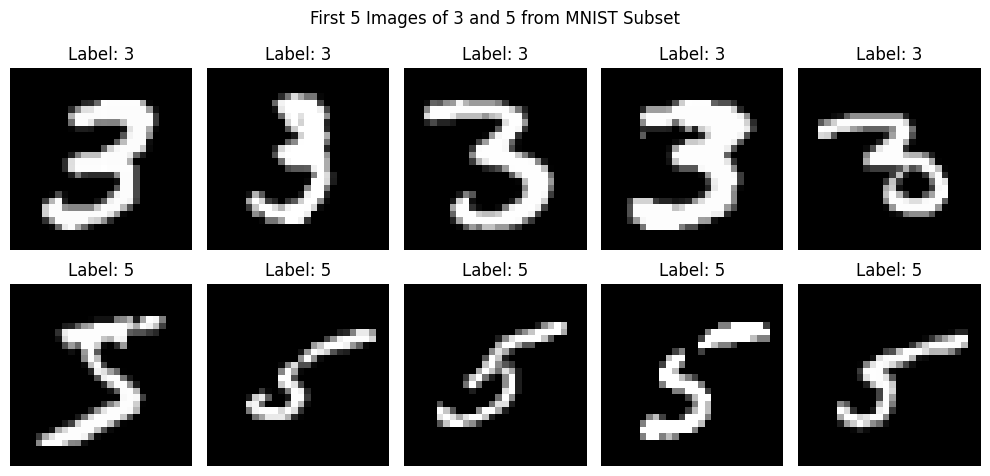

In [37]:
images_3 = X[y == 0]   # original digit 3
images_5 = X[y == 1]   # original digit 5

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images to display.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.tight_layout()
    plt.show()

Step 3: Initialize weights and bias

In [38]:
weights = np.zeros(X.shape[1])   # one weight for each pixel
bias = 0
learning_rate = 0.1
epochs = 100

Step 4: Decision / Activation function

In [39]:
def decision_function(X, weights, bias):
    """
    Compute predicted labels using perceptron step function.

    Parameters:
        X (numpy.ndarray): Input features of shape (n_samples, n_features)
        weights (numpy.ndarray): Weight vector
        bias (float): Bias term

    Returns:
        numpy.ndarray: Predicted labels (0 or 1)
    """
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

Step 5: Perceptron training algorithm

In [40]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train perceptron using the perceptron learning rule.

    Parameters:
        X (numpy.ndarray): Features of shape (n_samples, n_features)
        y (numpy.ndarray): True binary labels of shape (n_samples,)
        weights (numpy.ndarray): Initial weights
        bias (float): Initial bias
        learning_rate (float): Learning rate
        epochs (int): Number of epochs

    Returns:
        weights (numpy.ndarray): Trained weights
        bias (float): Trained bias
        accuracy (float): Final training accuracy
    """
    for epoch in range(epochs):
        errors = 0

        for i in range(len(X)):
            # Compute weighted sum for one sample
            output = np.dot(X[i], weights) + bias

            # Apply step function
            y_pred = 1 if output >= 0 else 0

            # Update only if prediction is wrong
            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)
                errors += 1

        # Calculate accuracy after each epoch
        epoch_predictions = decision_function(X, weights, bias)
        accuracy = np.mean(epoch_predictions == y)

        print(f"Epoch {epoch + 1}: Accuracy = {accuracy:.4f}, Errors = {errors}")

        # Stop early if all samples classified correctly
        if errors == 0:
            print("Training converged early.")
            break

    return weights, bias, accuracy

Step 6: Train the perceptron

In [41]:
weights, bias, accuracy = train_perceptron(
    X, y, weights, bias, learning_rate=learning_rate, epochs=epochs
)

print("\nThe Final Accuracy is:", accuracy)

# ------------------------------
# Step 7: Final predictions
# ------------------------------
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

Epoch 1: Accuracy = 0.9325, Errors = 231
Epoch 2: Accuracy = 0.9456, Errors = 172
Epoch 3: Accuracy = 0.9278, Errors = 160
Epoch 4: Accuracy = 0.9500, Errors = 144
Epoch 5: Accuracy = 0.9475, Errors = 140
Epoch 6: Accuracy = 0.9697, Errors = 136
Epoch 7: Accuracy = 0.9606, Errors = 110
Epoch 8: Accuracy = 0.9570, Errors = 121
Epoch 9: Accuracy = 0.9529, Errors = 126
Epoch 10: Accuracy = 0.9613, Errors = 119
Epoch 11: Accuracy = 0.9259, Errors = 110
Epoch 12: Accuracy = 0.9602, Errors = 115
Epoch 13: Accuracy = 0.9719, Errors = 94
Epoch 14: Accuracy = 0.9748, Errors = 109
Epoch 15: Accuracy = 0.9734, Errors = 100
Epoch 16: Accuracy = 0.9438, Errors = 94
Epoch 17: Accuracy = 0.9460, Errors = 108
Epoch 18: Accuracy = 0.9570, Errors = 103
Epoch 19: Accuracy = 0.9646, Errors = 107
Epoch 20: Accuracy = 0.9540, Errors = 93
Epoch 21: Accuracy = 0.9369, Errors = 82
Epoch 22: Accuracy = 0.9730, Errors = 85
Epoch 23: Accuracy = 0.9734, Errors = 74
Epoch 24: Accuracy = 0.9788, Errors = 87
Epoch 25

Step 8: Visualize misclassified images

Total Misclassified Samples: 36


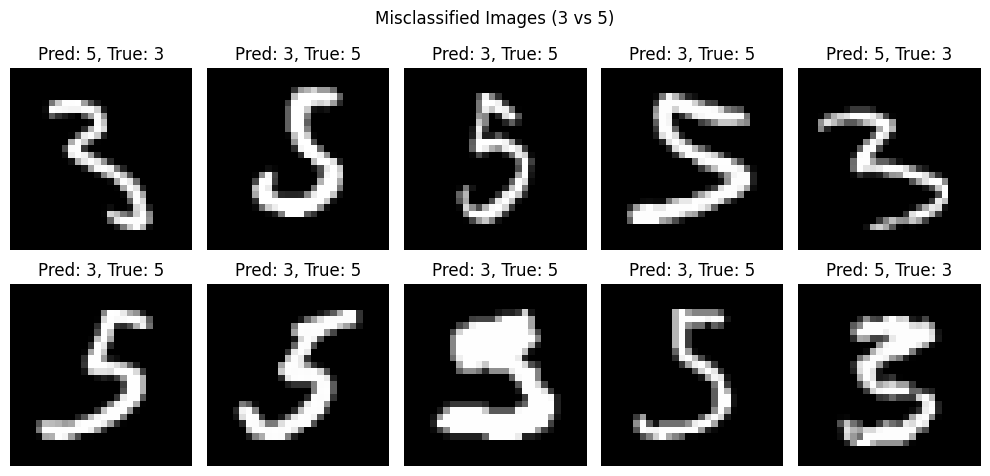

In [42]:
misclassified_idx = np.where(y_pred != y)[0]

print("Total Misclassified Samples:", len(misclassified_idx))

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # show first 10
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")

        # Convert binary labels back to original digits for display
        pred_label = 5 if y_pred[idx] == 1 else 3
        true_label = 5 if y[idx] == 1 else 3

        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")

    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

Question 8:
What does misclassified_idx store?

misclassified_idx stores the indices of all data samples where the predicted labels do not match the true labels. It is obtained by comparing the predicted output with the actual labels and identifying the positions where they are different. These indices are then used to retrieve and visualize the misclassified images from the dataset, allowing us to analyze where the model made mistakes.

What does it mean if:

“All images were correctly classified!”



If the output shows “All images were correctly classified!”, it means that the perceptron model predicted every sample correctly, achieving 100% accuracy on the dataset. This indicates that the data is likely simple or sufficiently linearly separable for the perceptron to learn an accurate decision boundary without any errors. However, in practical scenarios, especially with more complex datasets like handwritten digits (e.g., 3 vs 5), perfect classification is uncommon and may also suggest that the dataset is small, less diverse, or easier than typical real-world data.